# Data Science — Pertemuan 11: Unsupervised Learning — Clustering

## Identitas Mahasiswa

**Nama:** Amin Siddik Rangkuti  
**NIM:** 220401010124  
**Kelas:** IF405  
**Program Studi:** PJJ Informatika  
**Mata Kuliah:** Data Science  
**Universitas:** Universitas Siber Asia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/main/Pertemuan_11_AminSiddikRangkuti_220401010124.ipynb)

## Tujuan Praktikum

Notebook ini dibuat untuk memahami konsep **Unsupervised Learning**, khususnya **clustering**. Algoritma yang digunakan adalah **K-Means Clustering** dan **Hierarchical Clustering**. Praktikum ini juga menggunakan **Elbow Method** dan **Silhouette Score** untuk membantu menentukan jumlah cluster yang baik.

## Ringkasan Materi

**Clustering** adalah teknik pengelompokan data tanpa label. Data yang memiliki karakteristik mirip akan masuk ke cluster yang sama, sedangkan data yang berbeda akan masuk ke cluster lain.

**K-Means** bekerja dengan menentukan jumlah cluster di awal, lalu mencari centroid atau titik pusat cluster. Prosesnya terdiri dari assignment step dan update step sampai hasilnya stabil.

**Hierarchical Clustering** membentuk struktur bertingkat seperti pohon atau dendrogram. Metode ini cocok untuk melihat hubungan antar data dan tidak harus menentukan jumlah cluster sejak awal.

## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Agar hasil random tetap sama setiap dijalankan
np.random.seed(42)

## 2. Membuat Dataset Contoh

Dataset dibuat menyerupai data pelanggan berdasarkan **pendapatan tahunan** dan **skor belanja**. Tujuannya adalah mengelompokkan pelanggan berdasarkan pola yang mirip.

In [ ]:
# Membuat data simulasi pelanggan
n = 50
cluster_1 = np.random.normal(loc=[35, 75], scale=[6, 8], size=(n, 2))
cluster_2 = np.random.normal(loc=[70, 30], scale=[8, 7], size=(n, 2))
cluster_3 = np.random.normal(loc=[85, 80], scale=[7, 6], size=(n, 2))
cluster_4 = np.random.normal(loc=[25, 25], scale=[5, 6], size=(n, 2))

X = np.vstack([cluster_1, cluster_2, cluster_3, cluster_4])

df = pd.DataFrame(X, columns=['pendapatan_tahunan', 'skor_belanja'])
df['pendapatan_tahunan'] = df['pendapatan_tahunan'].round(2)
df['skor_belanja'] = df['skor_belanja'].round(2)

df.head()

,pendapatan_tahunan,skor_belanja
0,37.98,73.89
1,38.89,87.18
2,33.60,73.13
3,44.48,81.14
4,32.18,79.34


## 3. Melihat Informasi Dataset

In [ ]:
print('Jumlah baris dan kolom:', df.shape)
df.describe()

Jumlah baris dan kolom: (200, 2)


,pendapatan_tahunan,skor_belanja
count,200.000000,200.000000
mean,53.740750,52.731300
std,25.584444,25.559605
min,14.380000,16.560000
25%,29.847500,27.322500
50%,49.565000,54.070000
75%,76.877500,77.540000
max,101.200000,103.120000


## 4. Visualisasi Data Awal

Pada tahap ini data belum memiliki label cluster. Karena itu titik-titik hanya ditampilkan sebagai data mentah.

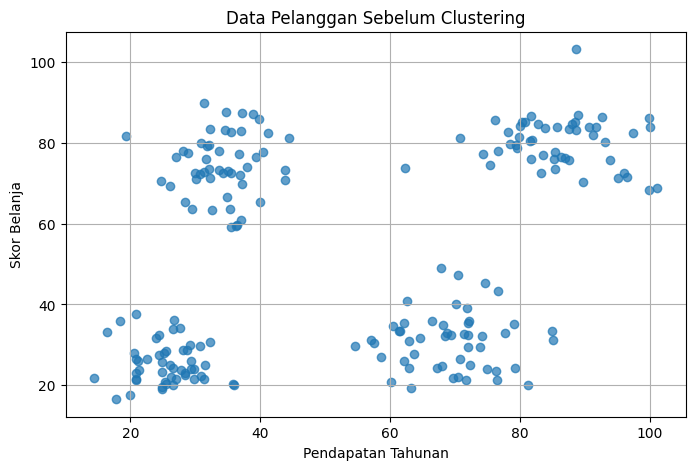

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], alpha=0.7)
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.title('Data Pelanggan Sebelum Clustering')
plt.grid(True)
plt.show()

## 5. Scaling Data

K-Means menggunakan jarak antar titik data, sehingga data perlu dilakukan **scaling** agar setiap fitur memiliki skala yang seimbang.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['pendapatan_tahunan', 'skor_belanja']])

pd.DataFrame(X_scaled, columns=['pendapatan_tahunan_scaled', 'skor_belanja_scaled']).head()

,pendapatan_tahunan_scaled,skor_belanja_scaled
0,-0.617574,0.829895
1,-0.581917,1.351161
2,-0.789202,0.800086
3,-0.362876,1.114258
4,-0.844844,1.043657


## 6. Elbow Method

**Elbow Method** digunakan untuk mencari jumlah cluster terbaik. Nilai WCSS/Inertia akan semakin kecil ketika jumlah cluster bertambah. Titik siku atau elbow menunjukkan jumlah cluster yang cukup baik.

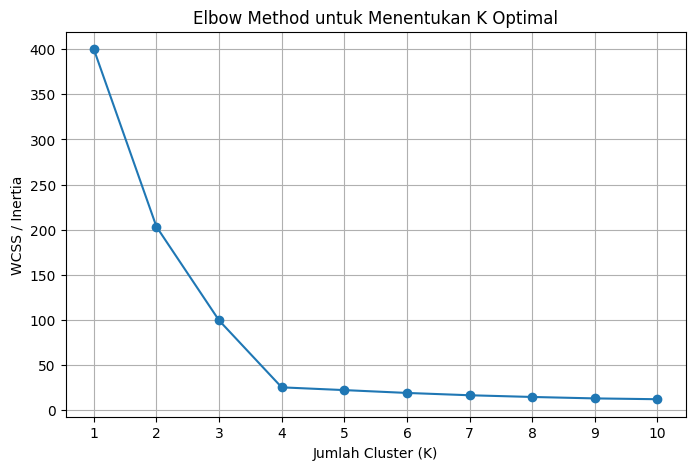

,K,WCSS
0,1,400.000000
1,2,203.362362
2,3,99.517580
3,4,25.406451
4,5,22.358364
5,6,19.218270
6,7,16.649144
7,8,14.759906
8,9,13.161628
9,10,12.255630


In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xticks(K_range)
plt.grid(True)
plt.show()

pd.DataFrame({'K': list(K_range), 'WCSS': wcss})

## 7. Silhouette Score

**Silhouette Score** digunakan untuk melihat kualitas cluster. Nilainya berkisar dari -1 sampai 1. Semakin mendekati 1, semakin baik pemisahan antar cluster.

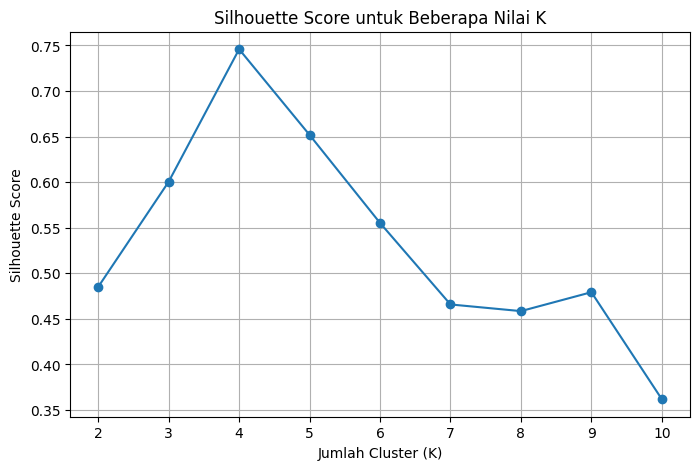

,K,Silhouette Score
0,2,0.485088
1,3,0.600463
2,4,0.745853
3,5,0.651818
4,6,0.555270
5,7,0.465827
6,8,0.458523
7,9,0.479269
8,10,0.361854


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Beberapa Nilai K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

pd.DataFrame({'K': list(range(2, 11)), 'Silhouette Score': silhouette_scores})

## 8. K-Means Clustering

Berdasarkan pola data dan hasil Elbow Method, pada contoh ini digunakan **K = 4**.

In [ ]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print('WCSS akhir:', round(kmeans.inertia_, 3))
print('Silhouette Score:', round(silhouette_score(X_scaled, df['cluster_kmeans']), 3))

df.head()

WCSS akhir: 25.406
Silhouette Score: 0.746


,pendapatan_tahunan,skor_belanja,cluster_kmeans
0,37.98,73.89,2
1,38.89,87.18,2
2,33.60,73.13,2
3,44.48,81.14,2
4,32.18,79.34,2


## 9. Visualisasi Hasil K-Means

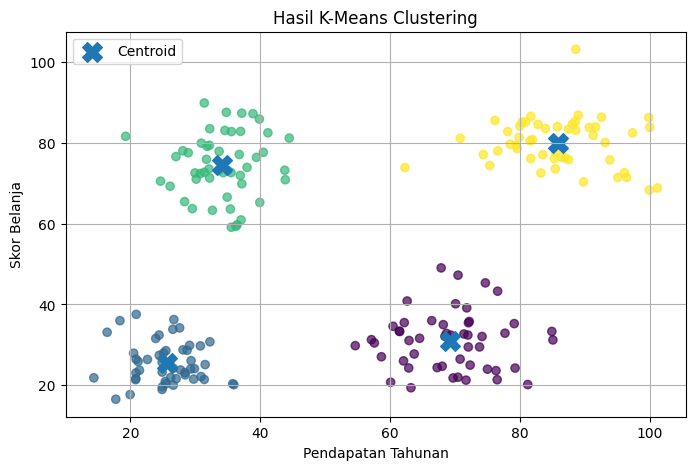

In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster_kmeans'], alpha=0.7)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.title('Hasil K-Means Clustering')
plt.legend()
plt.grid(True)
plt.show()

## 10. Interpretasi Cluster K-Means

Interpretasi dilakukan dengan melihat rata-rata pendapatan dan skor belanja pada setiap cluster.

In [ ]:
summary = df.groupby('cluster_kmeans')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2)
summary['jumlah_data'] = df['cluster_kmeans'].value_counts().sort_index().values
summary

,pendapatan_tahunan,skor_belanja,jumlah_data
cluster_kmeans,,,
0,69.24,30.98,50
1,25.64,25.52,50
2,34.19,74.42,50
3,85.90,80.00,50


## 11. Hierarchical Clustering dan Dendrogram

Dendrogram membantu melihat proses penggabungan cluster secara bertahap. Pada contoh ini digunakan metode **Ward linkage**.

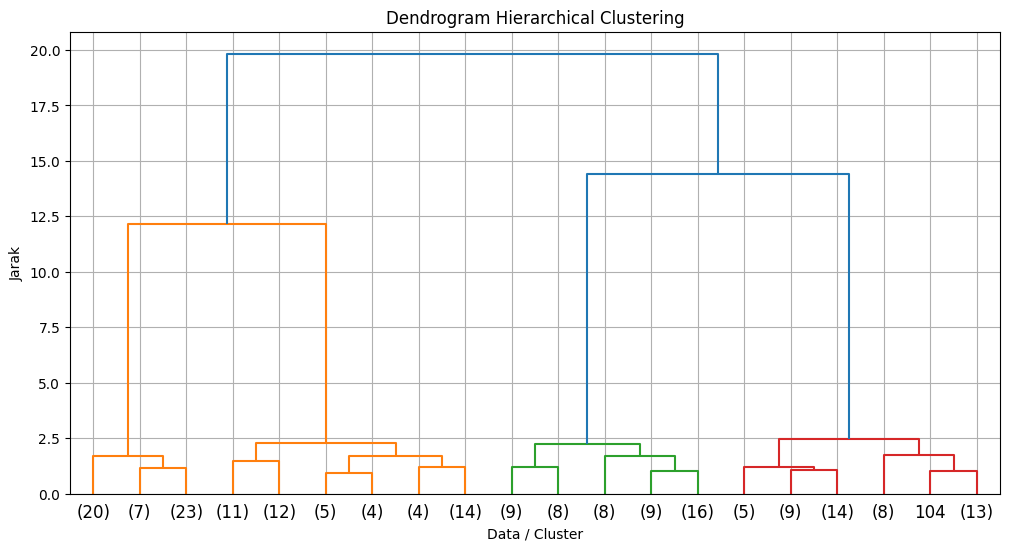

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Dendrogram Hierarchical Clustering')
plt.xlabel('Data / Cluster')
plt.ylabel('Jarak')
plt.grid(True)
plt.show()

## 12. Agglomerative Clustering

Setelah melihat dendrogram, kita mencoba membuat 4 cluster menggunakan **Agglomerative Clustering**.

In [ ]:
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hierarchical'] = agg.fit_predict(X_scaled)

print('Silhouette Score Hierarchical:', round(silhouette_score(X_scaled, df['cluster_hierarchical']), 3))
df.head()

Silhouette Score Hierarchical: 0.746


,pendapatan_tahunan,skor_belanja,cluster_kmeans,cluster_hierarchical
0,37.98,73.89,2,2
1,38.89,87.18,2,2
2,33.60,73.13,2,2
3,44.48,81.14,2,2
4,32.18,79.34,2,2


## 13. Visualisasi Hasil Hierarchical Clustering

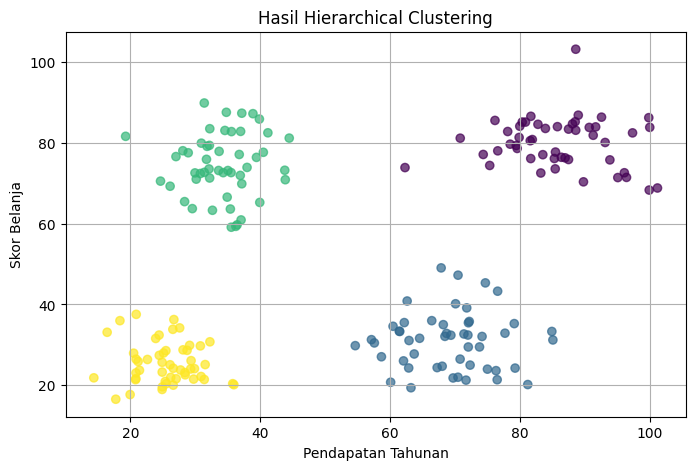

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster_hierarchical'], alpha=0.7)
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.title('Hasil Hierarchical Clustering')
plt.grid(True)
plt.show()

## 14. Perbandingan K-Means dan Hierarchical Clustering

In [ ]:
comparison = pd.DataFrame({
    'Metode': ['K-Means', 'Hierarchical'],
    'Jumlah Cluster': [4, 4],
    'Silhouette Score': [
        silhouette_score(X_scaled, df['cluster_kmeans']),
        silhouette_score(X_scaled, df['cluster_hierarchical'])
    ]
})
comparison['Silhouette Score'] = comparison['Silhouette Score'].round(3)
comparison

,Metode,Jumlah Cluster,Silhouette Score
0,K-Means,4,0.746
1,Hierarchical,4,0.746


## Kesimpulan

Pada Pertemuan 11, saya mempelajari **Unsupervised Learning** untuk mengelompokkan data tanpa label menggunakan **K-Means** dan **Hierarchical Clustering**. **Elbow Method**, Silhouette Score, dan dendrogram membantu menilai jumlah cluster yang sesuai. Pada dataset contoh, penggunaan 4 cluster memberikan segmentasi pelanggan yang cukup jelas berdasarkan pendapatan tahunan dan skor belanja.

**Keterbatasan:** hasil clustering dipengaruhi oleh pemilihan fitur, skala data, jumlah cluster, serta bentuk distribusi data. Praktikum ini masih menggunakan data contoh dua dimensi. Pertanyaan lanjutan adalah apakah jumlah cluster tetap optimal jika digunakan fitur pelanggan yang lebih banyak atau dataset nyata dengan pola yang lebih kompleks.